<a href="https://colab.research.google.com/github/hfelizzola/Curso-Ciencia-de-Datos-con-Python/blob/main/4_machine_learning/7_Ensamble_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Métodos de Ensamble: Random Forest

In [30]:
# Cargar librerias necesarias
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split  # División de datos en entrenamiento/prueba
from sklearn.ensemble import RandomForestClassifier  # Modelo de ensamble basado en 1rboles
from sklearn.linear_model import LogisticRegression  # Modelo de clasificación lineal
from sklearn.tree import DecisionTreeClassifier  # Modelo de clasificación de 1rbol individual
from sklearn.model_selection import GridSearchCV  # Búsqueda exhaustiva de hiperparámetros
from sklearn.metrics import classification_report, roc_curve, auc  # Métricas de evaluación de clasificación
from sklearn.metrics import precision_recall_fscore_support  # Cálculo de precisión, recall y f-score

# Pipeline de preprocesamiento
from sklearn.pipeline import Pipeline  # Ensamblaje de pasos de procesamiento y modelado
from sklearn.compose import ColumnTransformer  # Aplicación de transformaciones por columnas
from sklearn.preprocessing import StandardScaler, OneHotEncoder  # Escalamiento y codificación de variables

# Balaceo de Clases
from imblearn.over_sampling import SMOTE  # Técnica para balancear clases minoritarias
from imblearn.pipeline import Pipeline as ImbPipeline

In [7]:
# Para conectarse con google drive
from google.colab import drive
drive.mount('/gdrive')
# Configurar directorio de trabajo
os.chdir('/gdrive/MyDrive/Colab Notebooks/Ciencia de Datos con Python')
# Verificar los archivos de las carpetas
!ls

Drive already mounted at /gdrive; to attempt to forcibly remount, call drive.mount("/gdrive", force_remount=True).
1_fundamentos_pyhton.ipynb
2_numpy_pandas_ciencia_datos.ipynb
3_visualización_analisis_exploratorio.ipynb
4_regresion_lineal.ipynb
4_regresion_lineal_mejorado.ipynb
5_Regresion_Logistica.ipynb
5_Regresion_Logistica_Mejorado.ipynb
6_Arboles_de_Decision.ipynb
7_Ensamble_Random_Forest_GBM.ipynb
bank_marketing.csv
cupones.csv
cupones.gsheet
data_caso_retail
gastos_medicos.xlsx
house-prices-advanced-regression-techniques
house-prices-advanced-regression-techniques.zip
incumplimiento_credito.csv
publicidad.csv
taller3_modelo_clasificacion.ipynb
ventas.csv
wholesale_customers_data.csv


### 1. Preparación de Datos y Balanceo de Clases
Primero cargamos el dataset y separamos las características (X) de la etiqueta (y). Dado que los problemas de crédito suelen estar desbalanceados, aplicaremos SMOTE.

In [8]:
# Cargar datos
df = pd.read_csv('incumplimiento_credito.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   saldo_cuenta(millones)   1000 non-null   object
 1   duracion_prestamo_meses  1000 non-null   int64 
 2   historial_crediticio     1000 non-null   object
 3   proposito                1000 non-null   object
 4   monto(millones)          1000 non-null   int64 
 5   saldo_ahorros(millones)  1000 non-null   object
 6   antiguedad_empleo        1000 non-null   object
 7   tasa_cuotas              1000 non-null   int64 
 8   estado_personal          1000 non-null   object
 9   otros_deudores           1000 non-null   object
 10  historial_residencia     1000 non-null   int64 
 11  propiedad                1000 non-null   object
 12  edad                     1000 non-null   int64 
 13  plan_cuotas              1000 non-null   object
 14  vivienda                 1000 non-null   

In [10]:
# Asumiendo que la columna objetivo es la última o tiene un nombre similar a 'default'
# Ajusta el nombre de la columna si es necesario
X = df.drop(columns=['incumplimiento'])
y = df['incumplimiento']

# Identificar columnas por tipo
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

### 2. Pipeline de Preprocesamiento
Construiremos un `Pipeline` que integre el escalado, la codificación y el modelo `RandomForestClassifier`. Luego, buscaremos los mejores parámetros.

In [11]:
# Definir transformadores
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Crear el Pipeline
clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

### 3. Ajuste de Hiperparámetros

In [34]:
# Definir malla de hiperparámetros para ajustar
param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 5, 10, 15, 20],
}

# GridSearchCV
grid_search = GridSearchCV(clf_pipeline, param_grid, cv=3, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Extraer resultados del GridSearchCV a un DataFrame
results_df = pd.DataFrame(grid_search.cv_results_)


print(f"Mejores parámetros: {grid_search.best_params_}")

Mejores parámetros: {'classifier__max_depth': 20, 'classifier__n_estimators': 100}


In [35]:
# Imprimir los resultados de los primeros 10 experimentos
results_df.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier__max_depth,param_classifier__n_estimators,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.390628,0.016466,0.034374,0.001250,None,100,"{'classifier__max_depth': None, 'classifier__n...",0.427184,0.495238,0.428571,0.450331,0.031759,5
1,0.734763,0.006824,0.054274,0.007667,None,200,"{'classifier__max_depth': None, 'classifier__n...",0.419048,0.495413,0.421053,0.445171,0.035536,7
2,1.096214,0.015249,0.065263,0.000699,None,300,"{'classifier__max_depth': None, 'classifier__n...",0.403846,0.500000,0.438596,0.447481,0.039754,6
3,0.322399,0.002900,0.031541,0.000309,5,100,"{'classifier__max_depth': 5, 'classifier__n_es...",0.255814,0.177215,0.291667,0.241565,0.047799,15
4,0.628885,0.015793,0.045926,0.001082,5,200,"{'classifier__max_depth': 5, 'classifier__n_es...",0.258824,0.200000,0.279570,0.246131,0.033701,14
5,0.939142,0.007599,0.059462,0.000341,5,300,"{'classifier__max_depth': 5, 'classifier__n_es...",0.258824,0.222222,0.301075,0.260707,0.032219,13
6,0.357577,0.002337,0.034232,0.001706,10,100,"{'classifier__max_depth': 10, 'classifier__n_e...",0.340000,0.470588,0.469565,0.426718,0.061320,11
7,0.748492,0.047597,0.071842,0.033804,10,200,"{'classifier__max_depth': 10, 'classifier__n_e...",0.388350,0.485437,0.436364,0.436717,0.039637,10
8,1.701146,0.124441,0.110314,0.024982,10,300,"{'classifier__max_depth': 10, 'classifier__n_e...",0.352941,0.500000,0.418182,0.423708,0.060164,12
9,0.704952,0.034831,0.062503,0.001568,15,100,"{'classifier__max_depth': 15, 'classifier__n_e...",0.433962,0.500000,0.434783,0.456248,0.030939,2


<Figure size 1000x600 with 0 Axes>

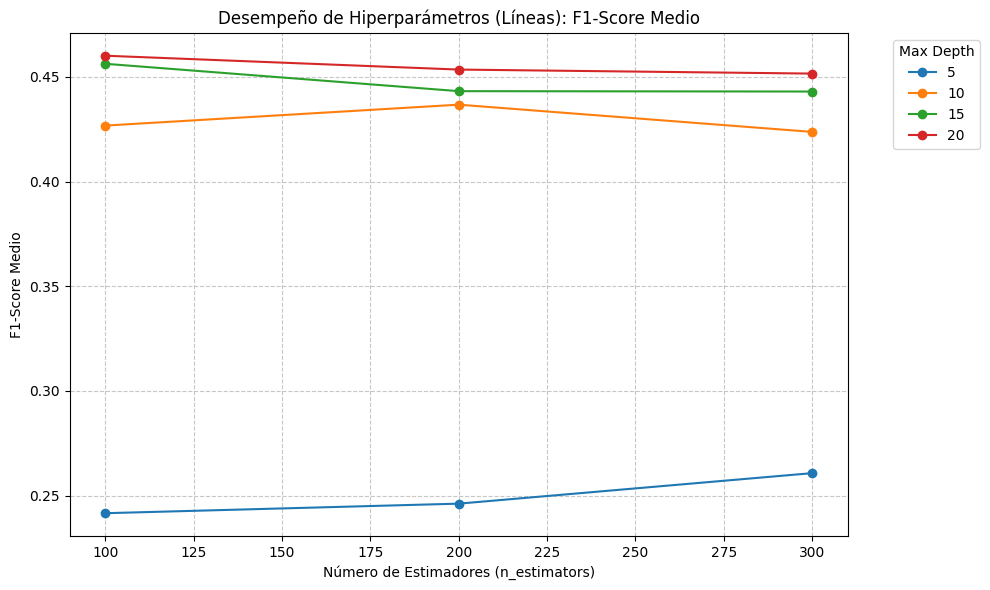

In [36]:
# Agrupar por los parámetros de interés y promediar el mean_test_score
# Esto evita el error de duplicados si hay otros parámetros (como min_samples_split) variando
pivot_table = results_df.groupby(['param_classifier__max_depth', 'param_classifier__n_estimators'])['mean_test_score'].mean().unstack()

# Graficar con líneas
plt.figure(figsize=(10, 6))
pivot_table.T.plot(marker='o', figsize=(10, 6))
plt.title('Desempeño de Hiperparámetros (Líneas): F1-Score Medio')
plt.xlabel('Número de Estimadores (n_estimators)')
plt.ylabel('F1-Score Medio')
plt.legend(title='Max Depth', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 4. Entrenamiento con Parámetros Óptimos y Reporte
Utilizamos el mejor estimador encontrado para predecir y evaluar con el `Classification Report` y la `Curva ROC`.

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.77      0.93      0.84       210
           1       0.68      0.36      0.47        90

    accuracy                           0.76       300
   macro avg       0.73      0.64      0.65       300
weighted avg       0.74      0.76      0.73       300



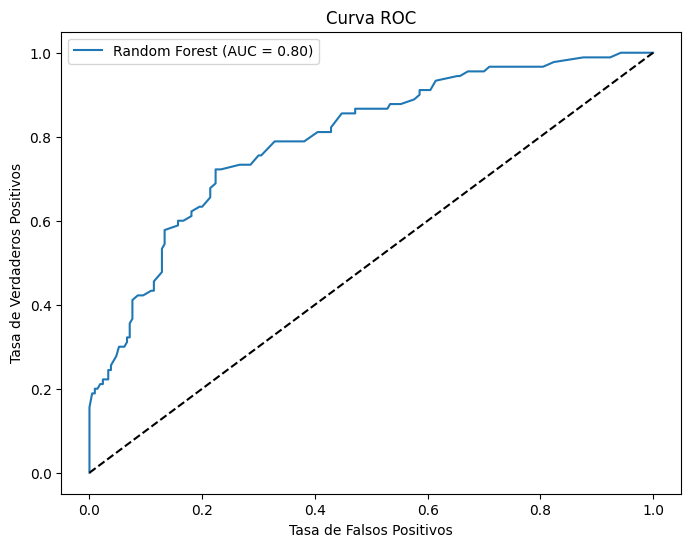

In [37]:
# El mejor modelo ya está entrenado en grid_search.best_estimator_
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Calcular Curva ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC')
plt.legend()
plt.show()

### 5. Balaceo de clase

In [38]:
# Definir el pipeline con balanceo de clases (SMOTE)
# Nota: El preprocesador debe ir antes del balanceo para manejar las variables categóricas
balanced_rf_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Entrenar el modelo con los datos de entrenamiento
balanced_rf_pipeline.fit(X_train, y_train)

# Evaluación rápida
y_pred_balanced = balanced_rf_pipeline.predict(X_test)
print("--- Reporte con Random Forest + SMOTE ---")
print(classification_report(y_test, y_pred_balanced))

--- Reporte con Random Forest + SMOTE ---
              precision    recall  f1-score   support

           0       0.80      0.89      0.84       210
           1       0.65      0.47      0.54        90

    accuracy                           0.76       300
   macro avg       0.72      0.68      0.69       300
weighted avg       0.75      0.76      0.75       300



### 6. Comparación de Múltiples Modelos
Para finalizar, entrenaremos un modelo rápido de Regresión Logística para comparar ambas curvas ROC en un mismo gráfico.

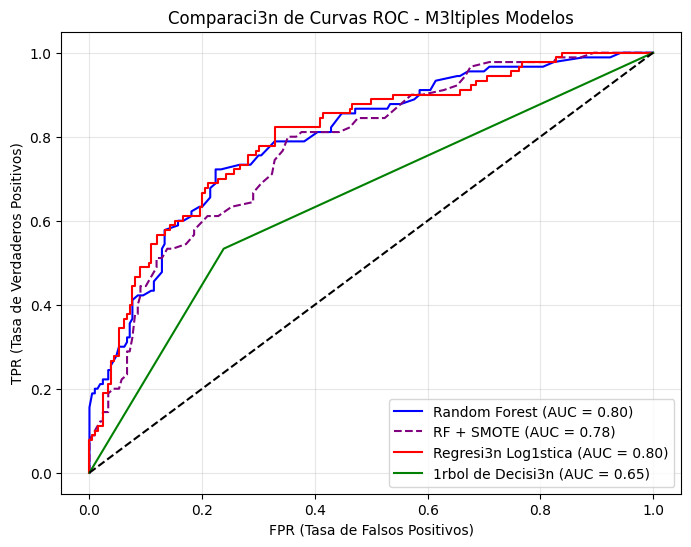

In [39]:
# 1. Pipeline para Regresión Logística
log_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])
log_pipeline.fit(X_train, y_train)
y_prob_log = log_pipeline.predict_proba(X_test)[:, 1]
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
roc_auc_log = auc(fpr_log, tpr_log)

# 2. Pipeline para árbol de Decisión
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])
dt_pipeline.fit(X_train, y_train)
y_prob_dt = dt_pipeline.predict_proba(X_test)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

# 3. Probabilidades para Random Forest con SMOTE
y_prob_smote = balanced_rf_pipeline.predict_proba(X_test)[:, 1]
fpr_smote, tpr_smote, _ = roc_curve(y_test, y_prob_smote)
roc_auc_smote = auc(fpr_smote, tpr_smote)

# 4. Graficar comparativa múltiple
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='blue', label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot(fpr_smote, tpr_smote, color='purple', linestyle='--', label=f'RF + SMOTE (AUC = {roc_auc_smote:.2f})')
plt.plot(fpr_log, tpr_log, color='red', label=f'Regresi3n Log1stica (AUC = {roc_auc_log:.2f})')
plt.plot(fpr_dt, tpr_dt, color='green', label=f'1rbol de Decisi3n (AUC = {roc_auc_dt:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Comparaci3n de Curvas ROC - M3ltiples Modelos')
plt.xlabel('FPR (Tasa de Falsos Positivos)')
plt.ylabel('TPR (Tasa de Verdaderos Positivos)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [40]:
def get_metrics(model, X, y, name):
    y_pred = model.predict(X)
    # Obtenemos métricas ponderadas (weighted)
    p, r, f, _ = precision_recall_fscore_support(y, y_pred, average='weighted')
    return {'Modelo': name, 'Precision': p, 'Recall': r, 'F1-Score': f}

# Recopilar métricas incluyendo el modelo con SMOTE
metrics_list = []
metrics_list.append(get_metrics(best_rf, X_test, y_test, 'Random Forest'))
metrics_list.append(get_metrics(balanced_rf_pipeline, X_test, y_test, 'RF + SMOTE'))
metrics_list.append(get_metrics(log_pipeline, X_test, y_test, 'Regresi3n Log1stica'))
metrics_list.append(get_metrics(dt_pipeline, X_test, y_test, '1rbol de Decisi3n'))

# Crear DataFrame comparativo
comparison_df = pd.DataFrame(metrics_list)
display(comparison_df.set_index('Modelo'))

,Precision,Recall,F1-Score
Modelo,,,
Random Forest,0.743781,0.756667,0.729779
RF + SMOTE,0.750867,0.763333,0.750895
Regresi3n Log1stica,0.774433,0.783333,0.775237
1rbol de Decisi3n,0.701394,0.693333,0.696881


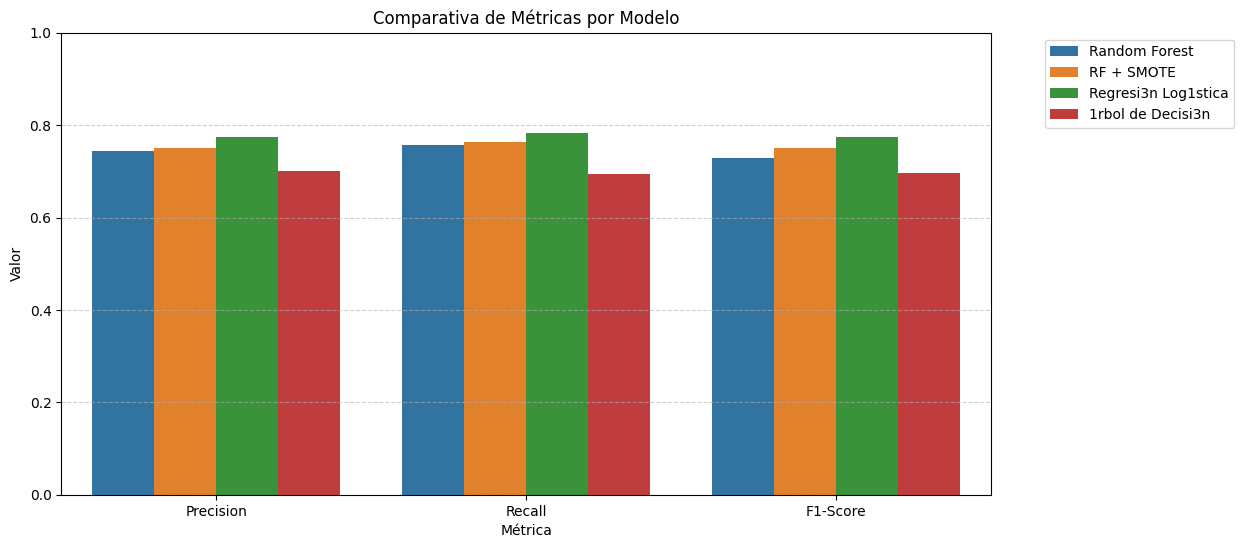

In [41]:
# Preparar los datos para graficar (formato largo)
df_plot = comparison_df.melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_plot, x='Métrica', y='Valor', hue='Modelo')
plt.title('Comparativa de Métricas por Modelo')
plt.ylim(0, 1)  # Las métricas van de 0 a 1
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()